In [ ]:
import pandas as pd
import json
from tqdm import tqdm

accentpth = "/work/nvme/bbjs/sbharadwaj/powsm/xeuspr/exp/data/tags/accent.shard0.jsonl"
langpth = "/work/nvme/bbjs/sbharadwaj/powsm/xeuspr/exp/data/tags/lang.shard0.jsonl"
datawithtag = {}

with open(accentpth, "r") as f:
    for line in tqdm(f):
        d = json.loads(line)
        d["accent"] = d["tag"]
        d.pop("tag")
        datawithtag[d["utt_id"]] = d

with open(langpth, "r") as f:
    for line in tqdm(f):
        d = json.loads(line)
        if d["utt_id"] in datawithtag:
            datawithtag[d["utt_id"]]["lang"] = d["tag"]

df = pd.DataFrame.from_dict(datawithtag, orient="index")
df.drop(columns=["utt_id"], inplace=True)

330131it [00:00, 505740.44it/s]
330131it [00:00, 514569.80it/s]


<Axes: ylabel='Frequency'>

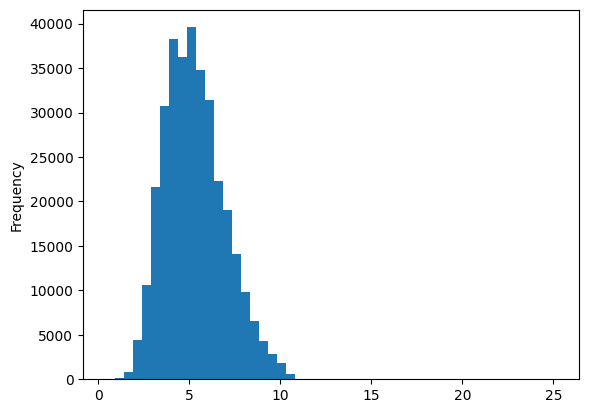

In [41]:
df.duration_sec.plot.hist(bins=50)

In [ ]:
df["lid"] = df.lang.apply(lambda x: x.split(":")[0].strip())
df["language"] = df.lang.apply(lambda x: "_".join(x.split(":")[1:]).strip())

In [11]:
df

,wavpath,accent,lang,lid,language
aaaaa_cv_train_0000000000000000003016976_pr,/work/hdd/bbjs/shared/powsm/s2t1/dump/raw/org/...,us,ha: Hausa,ha,Hausa
aaaaa_cv_train_0000000000000000003016992_pr,/work/hdd/bbjs/shared/powsm/s2t1/dump/raw/org/...,england,fa: Persian,fa,Persian
aaaaa_cv_train_0000000000000000003017008_pr,/work/hdd/bbjs/shared/powsm/s2t1/dump/raw/org/...,england,te: Telugu,te,Telugu
aaaaa_cv_train_0000000000000000003017024_pr,/work/hdd/bbjs/shared/powsm/s2t1/dump/raw/org/...,indian,te: Telugu,te,Telugu
aaaaa_cv_train_0000000000000000003017040_pr,/work/hdd/bbjs/shared/powsm/s2t1/dump/raw/org/...,us,pl: Polish,pl,Polish
...,...,...,...,...,...
aaaaa_cv_train_0000000000000000008303630_pr,/work/hdd/bbjs/shared/powsm/s2t1/dump/raw/org/...,us,fr: French,fr,French
aaaaa_cv_train_0000000000000000008303646_pr,/work/hdd/bbjs/shared/powsm/s2t1/dump/raw/org/...,us,fr: French,fr,French
aaaaa_cv_train_0000000000000000008303662_pr,/work/hdd/bbjs/shared/powsm/s2t1/dump/raw/org/...,england,fr: French,fr,French
aaaaa_cv_train_0000000000000000008303678_pr,/work/hdd/bbjs/shared/powsm/s2t1/dump/raw/org/...,england,fr: French,fr,French


In [ ]:
enmask = df.lid == "en"
df_en = df[enmask]
df_non_en = df[~enmask]

In [33]:
n_total = len(df)
n_en = len(df_en)
n_non_en = len(df_non_en)
print("English utterances: ", n_en, f"({n_en/n_total:.2%})")
print("Non-English utterances: ", n_non_en, f"({n_non_en/n_total:.2%})")
stats_en = df_en.accent.value_counts()
stats_en

English utterances:  45580 (13.81%)
Non-English utterances:  284551 (86.19%)


accent
us                28905
england            7694
canada             2860
australia          2588
indian             1430
scotland            567
african             549
ireland             399
newzealand          255
bermuda              82
singapore            70
malaysia             52
philippines          51
hongkong             35
wales                30
southatlandtic       13
Name: count, dtype: int64

In [ ]:
(stats_en / n_en) * 100

accent
us                63.415972
england           16.880211
canada             6.274682
australia          5.677929
indian             3.137341
scotland           1.243967
african            1.204476
ireland            0.875384
newzealand         0.559456
bermuda            0.179903
singapore          0.153576
malaysia           0.114085
philippines        0.111891
hongkong           0.076788
wales              0.065818
southatlandtic     0.028521
Name: count, dtype: float64

In [30]:
stats_en

,accent,percentage


Index(['wavpath', 'accent', 'lang', 'lid', 'language'], dtype='object')